#### todo:
- Research more strategies to improve the AUC score
- hyperparameter optimization - done
- feature selection and importance - SHapley Additive Explanations (will try later after the AUC and recall are improved)

## Imports

In [39]:
import mlflow
import optuna
import mlflow.sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from mlflow.models import infer_signature
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [2]:
tracking_uri = "http://127.0.0.1:5000/"
mlflow.set_tracking_uri(tracking_uri)
experiment = mlflow.set_experiment("my_paypal")

In [3]:
def visualize_class_balance(class_col: list[int], abs_nums: bool = False) -> None:
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(aspect="equal"))

    labels = ["0", "1"]
    title = "Class comparisons of the target variable - "
    
    total = sum(class_col)
    percentages = [f"{labels[i]} ({class_col[i] / total * 100:.3f}%)" for i in range(len(labels))]
    
    wedges, texts = ax.pie(class_col, wedgeprops=dict(width=0.5), startangle=-40)
    
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    kw = dict(arrowprops=dict(arrowstyle="-"),
              bbox=bbox_props, zorder=0, va="center")
    
    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1) / 2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        kw["arrowprops"].update({"connectionstyle": connectionstyle})

        if abs_nums is True:
            ax.annotate(class_col[i], xy=(x, y), xytext=(1.35*np.sign(x), 1.4*y),
                    horizontalalignment=horizontalalignment, **kw)
        else:    
            ax.annotate(percentages[i], xy=(x, y), xytext=(1.35*np.sign(x), 1.4*y),
                        horizontalalignment=horizontalalignment, **kw)

    if abs_nums is True:
        title += "absolute"
    else:
        title += "relative"
    
    ax.set_title(title)
    
    plt.show()

## Data loading and initial exploration 

In [4]:
df = pd.read_csv("my_paypal_creditcard.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


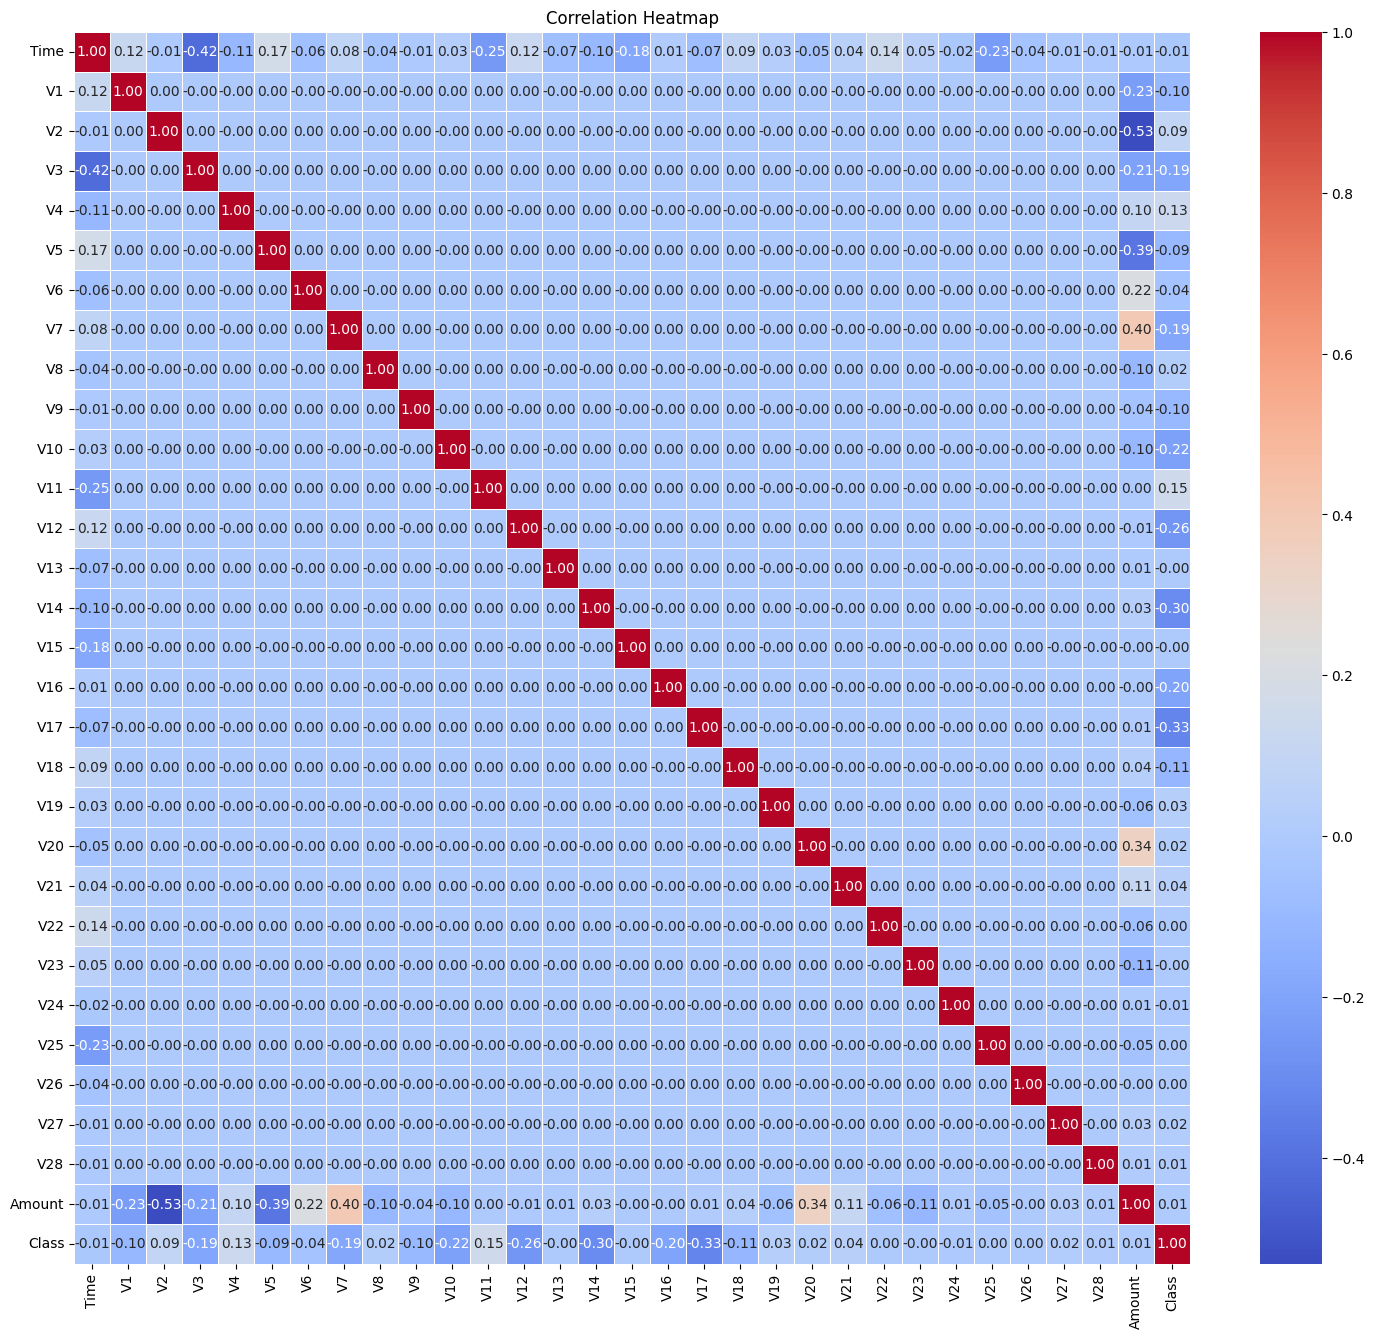

In [7]:
matrix = df.corr()

plt.figure(figsize=(18,16))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

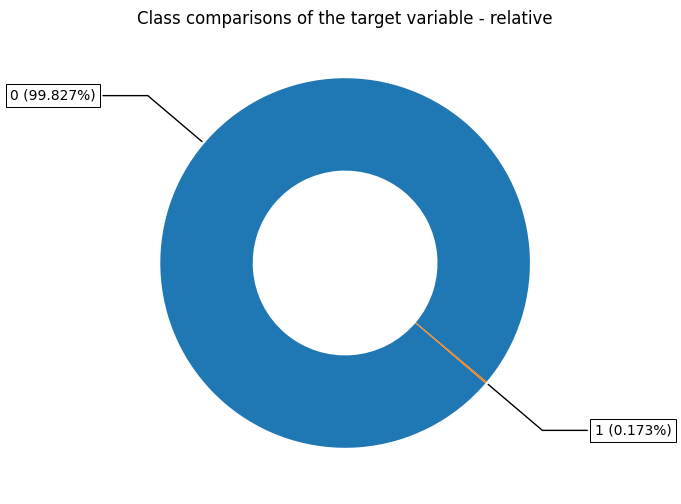

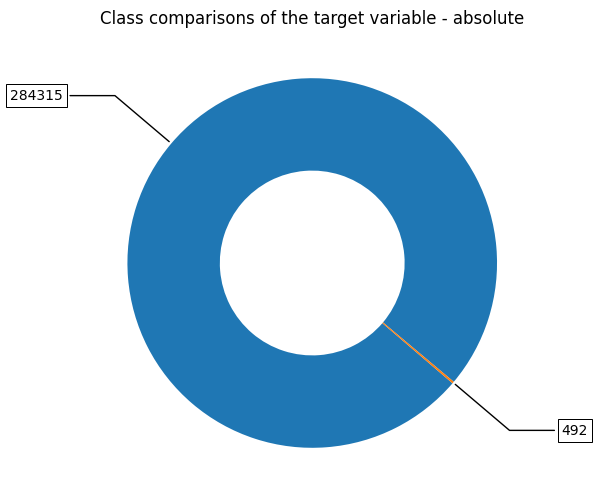

In [8]:
target_list = df["Class"].value_counts().to_list()
visualize_class_balance(target_list)
visualize_class_balance(target_list, abs_nums=True)

It is clear that the dataset is highly imbalanced. In some of my previous projects I have used some oversampling approaches such as SMOTE. In this case I will implement it as well influenced by this paper: https://drive.google.com/file/d/1WOHXFXO5xF-zQxotg4Hr0it_3SPDFrvx/view <br> Moreover, based on it, I will implement LogisticRegression as a baseline model and utilize Random Forest Classifier for main model, having in mind, the paper suggests it is the best among the tested algorithms. Below I have listed a comparison of different algorithms that I have already tested on this data. The main goal is to achieve high Area Under the Precision-Recall Curve. While trying to minimize the lost transaction fees, I will focus on lowering to a minimum the false-positives because such transactions would have a huge negative impact on any bank.

## Feature selection based on the correlation matrix above

In [9]:
df = df.drop(columns=["V13", "V15", "V22", "V23", "V25", "V26"])

## Train/Test split

In [44]:
X = df.drop(columns=["Class"])
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=0.3)

## Balancing data with oversampling - SMOTE

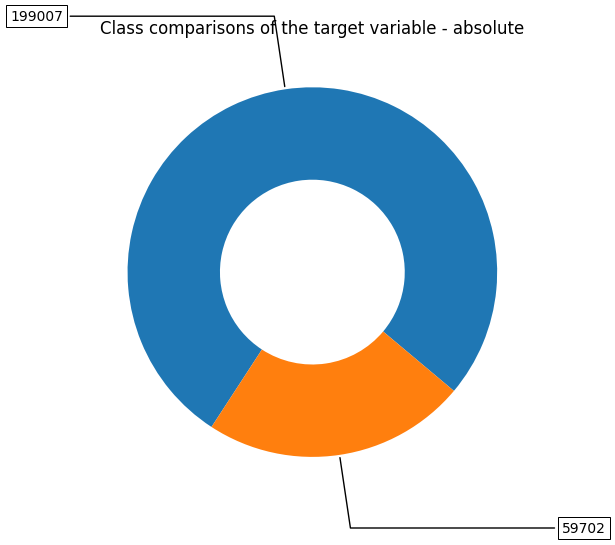

In [47]:
smote = SMOTE( # all from the search optimization below
    sampling_strategy=0.3, 
    k_neighbors=7
)
X_train, y_train = smote.fit_resample(X_train, y_train)
target_list = y_train.value_counts().to_list()
visualize_class_balance(target_list, abs_nums=True)

## Baseline classification model

In [11]:
baseline_lr = LogisticRegression()
baseline_lr.fit(X_train, y_train)
y_pred = baseline_lr.predict(X_test)

/Users/nikolaykirilov/Documents/University/qwasar/my_paypal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85308
           1       0.73      0.59      0.65       135

    accuracy                           1.00     85443
   macro avg       0.87      0.79      0.82     85443
weighted avg       1.00      1.00      1.00     85443



In [13]:
roc_auc_score(y_test, y_pred)

0.7924226202570553

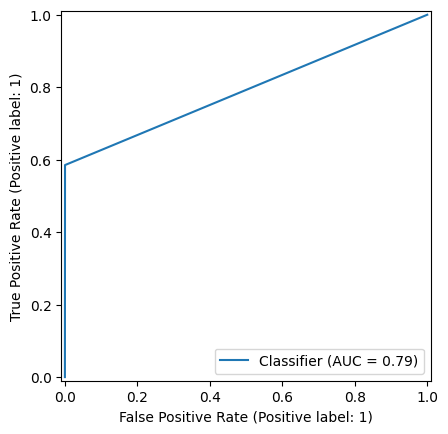

In [14]:
RocCurveDisplay.from_predictions(y_test, y_pred)
plt.show()

## Main model

In [49]:
%%time
with mlflow.start_run():
    model = RandomForestClassifier( # all from the search optimization below
        n_estimators=335,
        max_depth=6,
        min_samples_leaf=40,
        max_features="log2",
        max_samples=0.639,
        class_weight="balanced_subsample",
        random_state=1
    )
    model.fit(X_train, y_train)
    y_preds = model.predict(X_test) 
    for param, value in model.get_params().items():
        mlflow.log_param(param, value)

    signature = infer_signature(X_train, y_train)
    mlflow.sklearn.log_model(model, "model", signature=signature)
    
    roc_auc_metric = roc_auc_score(y_test, y_preds)
    mlflow.log_metrics(
        {
            "roc_auc_metric": roc_auc_metric,
            "test_size": len(y_test),
            "train_size": len(y_train),
            "test_support_1": len(y_test[y_test == 1]),
            "test_support_0": len(y_test[y_test == 0]),
            "train_support_1": len(y_train[y_train == 1]),
            "train_support_0": len(y_train[y_train == 0])
        }
    )

/Users/nikolaykirilov/Documents/University/qwasar/my_paypal/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2025/12/18 19:36:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run delicate-slug-860 at: http://127.0.0.1:5000/#/experiments/1/runs/9bde9415c43b4196a91e47715d8b6dc6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
CPU times: user 1min 41s, sys: 1.53 s, total: 1min 42s
Wall time: 1min 45s


In [50]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85308
           1       0.26      0.83      0.39       135

    accuracy                           1.00     85443
   macro avg       0.63      0.91      0.69     85443
weighted avg       1.00      1.00      1.00     85443



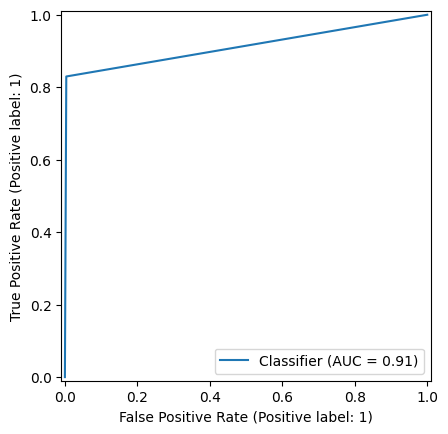

In [51]:
RocCurveDisplay.from_predictions(y_test, y_preds)
plt.show()

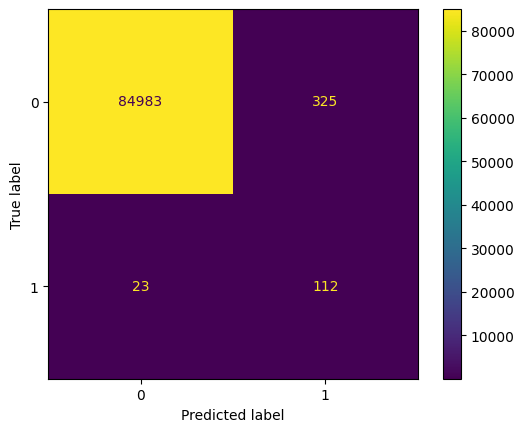

In [52]:
ConfusionMatrixDisplay.from_predictions(y_test, y_preds)
plt.show()

The first step after the pure data has been given to the model and tested on other algorithms, was to balance the data using SMOTE. After this operation the main model - RandomForestClassifier moved from <b>0.88 AUC </b> to <b>0.90 AUC</b>. Second step was to perform feature selection. Before it, the time to train the model was about <b> 3:25 min </b>, after removing the features with correlation <b> 0.00 </b> the time to train the model was lowered to <b> 2:39 min </b> while the AUC and F1 score stayed as high as with the removed columns. <br><br> After the hyperparameter search below, and adding `n_estimators=152` and `max_depth=7` the AUC increased to <b>0.91</b>. Then, I performed another search in which I optimized for `recall`, after it only the `n_estimators` increased to `165` and the AUC stayed <b>0.91</b>. After that, I performed on more search optimizing for `AUC` with more hyperparameters `n_estimators=335, max_depth=6, min_samples_leaf=40, max_features="log2", max_samples=0.639, class_weight="balanced_subsample", random_state=1` and different paramters for SMOTE - `sampling_strategy=0.3, k_neighbors=7`, however the AUC score did not improve and stayed <b>0.91</b> yet the time to train the model lowered to <b>1:41 min</b>.

<b><center> Here is a comparison of several algorithms on the current data WITHOUT any actions taken to optimize the given metrics: </center></b>


| Model        | F1 Score | AUC  |
|--------------|----------|------|
| LogisticRegression     |  0.82        | 0.79     |
| RandomForestClassifier     |  0.91        | 0.88     |
| SGDOneClassSVM      | 0.00          | 0.50     |
| EllipticEnvelope      |  0.00        |   0.26   |
| IsolationForest      |  0.00        |   0.11   |
| LocalOutlierFactor      |  0.00        |   0.42   |


## Hyperparameter search/optimization

In [42]:
%%time
def objective(trial):
    rf_params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 2, 50),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "max_samples": trial.suggest_float("max_samples", 0.5, 0.8),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample"]),
        "random_state": 1,
    }
    
    k_neighbors = trial.suggest_int("k_neighbors", 1, 7)
    sampling_strategy = trial.suggest_float("sampling_strategy", 0.1, 0.5)

    model_pipeline = Pipeline([
        ("smote", SMOTE(k_neighbors=k_neighbors, sampling_strategy=sampling_strategy, random_state=1)),
        ("classifier", RandomForestClassifier(**rf_params))
    ])

    score = cross_val_score(model_pipeline, X, y, cv=3, scoring="roc_auc")
    
    return score.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print(f"Best Accuracy: {study.best_value}")
print(f"Best Hyperparameters: {study.best_params}")

[I 2025-12-18 16:58:17,959] A new study created in memory with name: no-name-91930e75-059d-4ba1-b7ee-efc982424a71
[I 2025-12-18 17:02:54,577] Trial 0 finished with value: 0.9782262636356426 and parameters: {'n_estimators': 335, 'max_depth': 6, 'min_samples_leaf': 40, 'max_features': 'log2', 'max_samples': 0.6392443880988331, 'class_weight': 'balanced_subsample', 'k_neighbors': 7, 'sampling_strategy': 0.30540160433336194}. Best is trial 0 with value: 0.9782262636356426.
[I 2025-12-18 17:08:39,025] Trial 1 finished with value: 0.9712362953079978 and parameters: {'n_estimators': 223, 'max_depth': 24, 'min_samples_leaf': 22, 'max_features': 'log2', 'max_samples': 0.7498658216616497, 'class_weight': 'balanced', 'k_neighbors': 7, 'sampling_strategy': 0.1654469204113559}. Best is trial 0 with value: 0.9782262636356426.
[I 2025-12-18 17:11:21,545] Trial 2 finished with value: 0.9661850195890418 and parameters: {'n_estimators': 127, 'max_depth': 24, 'min_samples_leaf': 13, 'max_features': 'sqrt

Best Accuracy: 0.9782262636356426
Best Hyperparameters: {'n_estimators': 335, 'max_depth': 6, 'min_samples_leaf': 40, 'max_features': 'log2', 'max_samples': 0.6392443880988331, 'class_weight': 'balanced_subsample', 'k_neighbors': 7, 'sampling_strategy': 0.30540160433336194}
CPU times: user 59min 34s, sys: 1min 4s, total: 1h 38s
Wall time: 59min 39s
